# Initialize the oil-logistics-network database

**Run this once after switching machines** (laptop ↔ desktop). It executes the two source-of-truth notebooks in order:

1. **`build_oil_network.ipynb`** — drops & rebuilds the `oil_network` PostgreSQL schema from scratch (12 tables, 4 layers, 2 triggers).
2. **`load_asset_graph.ipynb`** — UPSERTs `asset_graph.json` into the schema (74 assets, 1 graph, 434 variable slots, 1 scenario).

Then a verification query confirms what's in the database.

**Assumes:** Postgres is running on `localhost:5432`, database `eia_crude` exists, user `eia_user` / password `eia_password`, and the venv at `./.venv/` has `psycopg2`, `sqlalchemy`, `pandas`, `jupyter`. If those aren't in place, set them up first.

**Idempotent:** safe to re-run any time. Re-running drops and rebuilds the schema, then UPSERTs the asset graph back.

## 0. Setup — locate `jupyter-nbconvert`

Picks the `jupyter-nbconvert` from the *same venv* this notebook is running in, so no PATH-fiddling is needed when switching machines.

In [1]:
import subprocess
import sys
from pathlib import Path

venv_scripts = Path(sys.executable).parent
for candidate in ("jupyter-nbconvert.exe", "jupyter-nbconvert"):
    NBCONVERT = venv_scripts / candidate
    if NBCONVERT.exists():
        break
else:
    NBCONVERT = "jupyter-nbconvert"  # fall back to PATH

print(f"Python:        {sys.executable}")
print(f"nbconvert:     {NBCONVERT}")
print(f"Working dir:   {Path.cwd()}")

def run_notebook(nb_name: str, timeout_s: int = 180) -> None:
    """Execute a notebook in-place; raise on any cell error."""
    print(f"\n=== Running {nb_name} ===")
    subprocess.run(
        [
            str(NBCONVERT),
            "--to", "notebook",
            "--execute", "--inplace",
            f"--ExecutePreprocessor.timeout={timeout_s}",
            nb_name,
        ],
        check=True,
    )
    print(f"=== {nb_name} done ===")

Python:        C:\Users\PedroPorfirio\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe
nbconvert:     jupyter-nbconvert
Working dir:   c:\Users\PedroPorfirio\OneDrive - Jabuticaba\Oil Network Project\Stage1\code


## 1. Build the schema

Drops `oil_network` if it exists and recreates it from scratch — `locations`, `assets`, `graphs`, `nodes`, `commodities`, `variable_types`, `node_types`, `variables`, `timeseries_types`, `timeseries`, `timeseries_data`, `scenarios`, `variable_assignments`, `node_type_default_formulas`, plus same-graph triggers. Open `build_oil_network.ipynb` afterwards to see the per-step output.

In [2]:
run_notebook("build_oil_network.ipynb")


=== Running build_oil_network.ipynb ===


=== build_oil_network.ipynb done ===


## 2. Load the starter asset graph

UPSERTs `asset_graph/asset_graph.json` into the freshly-built schema: 74 assets (64 physical, 10 abstract), 12 node types, 1 graph (`us_crude_starter`), 434 variable slots, 1 scenario (`starter_us_crude_2015_2025`) with the full coverage contract preserved in `scenarios.attributes`. Open `load_asset_graph.ipynb` afterwards to see the per-step output.

In [3]:
run_notebook("load_asset_graph.ipynb")


=== Running load_asset_graph.ipynb ===


=== load_asset_graph.ipynb done ===


## 3. Verify

Queries the live database and shows row counts per table. If everything is in place this should match the expected shape from `HANDOVER.md`.

In [4]:
import os

import pandas as pd
from sqlalchemy import create_engine, text
from IPython.display import display

PG_HOST   = os.environ.get("PG_HOST",   "localhost")
PG_PORT   = os.environ.get("PG_PORT",   "5432")
PG_DB     = os.environ.get("PG_DB",     "eia_crude")
PG_USER   = os.environ.get("PG_USER",   "eia_user")
PG_PASS   = os.environ.get("PG_PASS",   "eia_password")
PG_SCHEMA = os.environ.get("PG_SCHEMA", "oil_network")
PG_URL    = f"postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}"

engine = create_engine(
    PG_URL,
    connect_args={"options": f"-csearch_path={PG_SCHEMA},public"},
    future=True,
)

with engine.connect() as c:
    inv = pd.read_sql(text("""
        SELECT 'commodities'                       AS relation, count(*) AS n FROM commodities
        UNION ALL SELECT 'graphs',                              count(*) FROM graphs
        UNION ALL SELECT 'locations',                           count(*) FROM locations
        UNION ALL SELECT 'assets',                              count(*) FROM assets
        UNION ALL SELECT '  assets (physical)',                 count(*) FROM assets WHERE attributes->>'kind' = 'physical'
        UNION ALL SELECT '  assets (abstract)',                 count(*) FROM assets WHERE attributes->>'kind' = 'abstract'
        UNION ALL SELECT 'node_types',                          count(*) FROM node_types
        UNION ALL SELECT 'nodes',                               count(*) FROM nodes
        UNION ALL SELECT 'variable_types',                      count(*) FROM variable_types
        UNION ALL SELECT 'variables',                           count(*) FROM variables
        UNION ALL SELECT '  variables (non-relational)',        count(*) FROM variables WHERE related_node_id IS NULL
        UNION ALL SELECT '  variables (relational)',            count(*) FROM variables WHERE related_node_id IS NOT NULL
        UNION ALL SELECT 'timeseries_types',                    count(*) FROM timeseries_types
        UNION ALL SELECT 'timeseries',                          count(*) FROM timeseries
        UNION ALL SELECT 'timeseries_data',                     count(*) FROM timeseries_data
        UNION ALL SELECT 'scenarios',                           count(*) FROM scenarios
        UNION ALL SELECT 'variable_assignments',                count(*) FROM variable_assignments
        UNION ALL SELECT 'node_type_default_formulas',          count(*) FROM node_type_default_formulas
    """), c)
display(inv)

print(f"\n`{PG_SCHEMA}` is built and loaded. You can pick up where you left off — see HANDOVER.md.")

,relation,n
0,commodities,1
1,graphs,1
2,locations,219
3,assets,219
4,assets (physical),195
5,assets (abstract),24
6,node_types,19
7,nodes,219
8,variable_types,6
9,variables,1694



`oil_network_data_loader` is built and loaded. You can pick up where you left off — see HANDOVER.md.


## 4. Plot the graph

Reads the loaded `us_crude_starter` graph straight from Postgres and draws it. Nodes come from `nodes`; directed edges come from the relational `outflow` variables (each `outflow` row has `node_id` = source, `related_node_id` = target). Nodes are coloured by `node_type` and sized smaller for abstract aggregates (PADD views, observational aggregates). Layout is Kamada-Kawai for a clean topological view — geography-based plotting can come later.

Graph: 219 nodes, 409 edges


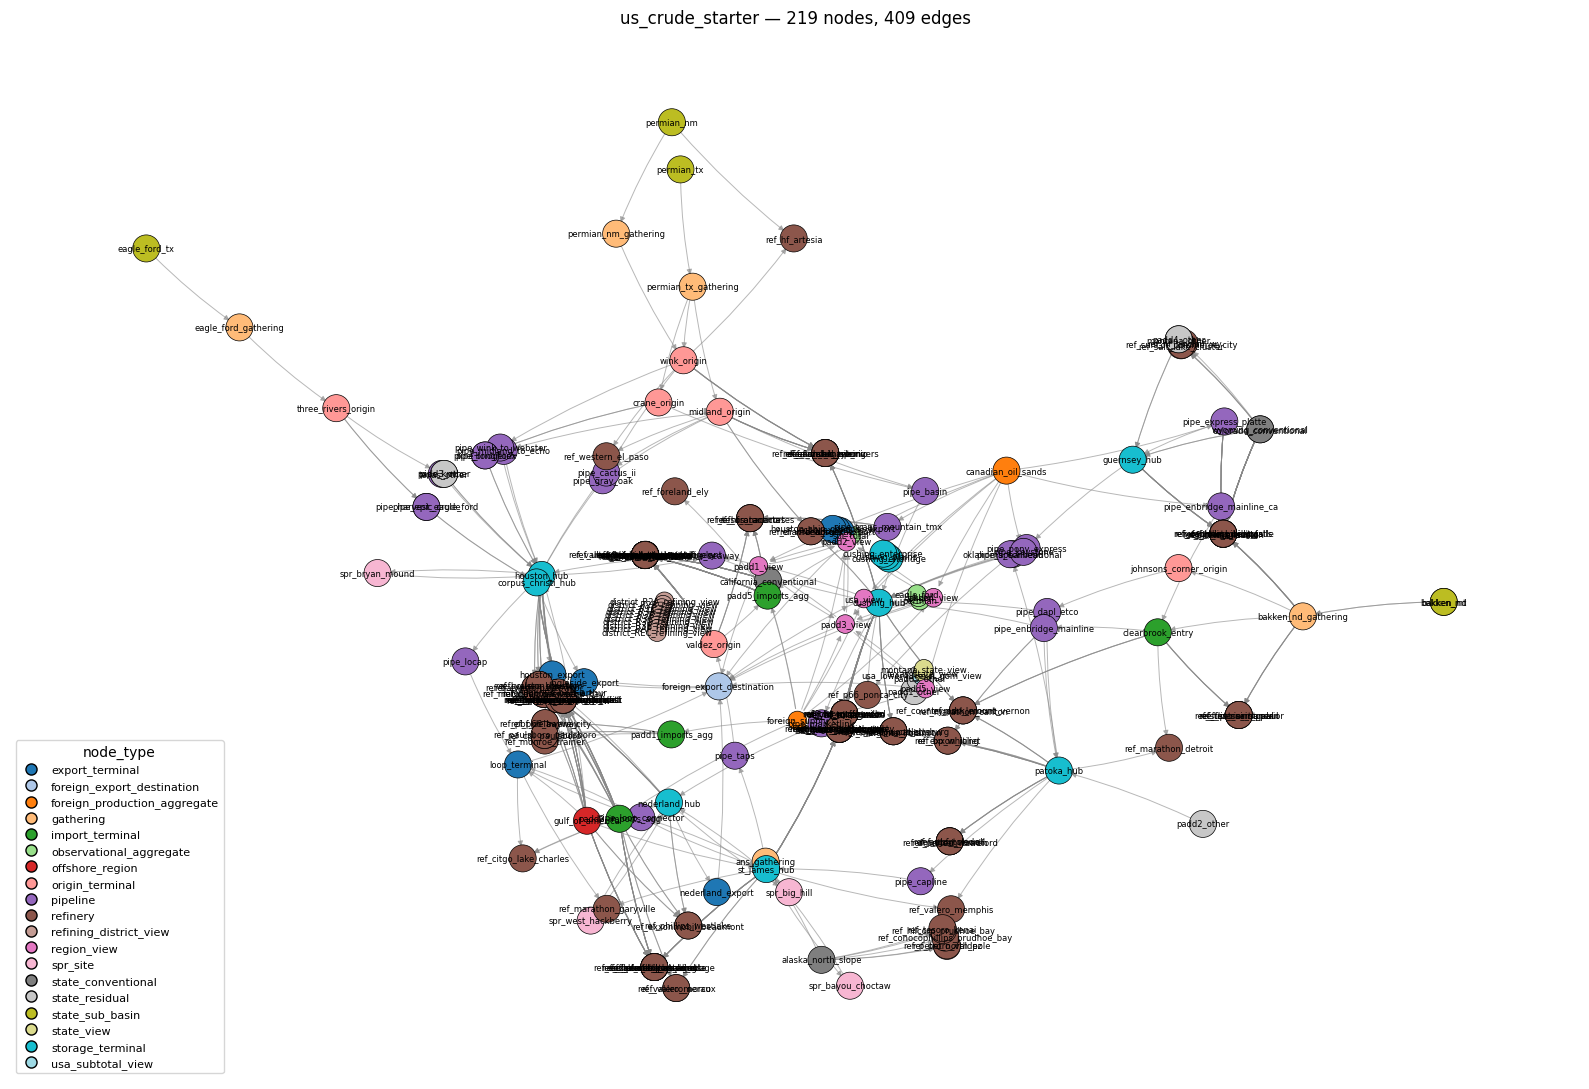

In [5]:
import matplotlib.pyplot as plt
import networkx as nx

GRAPH_ID  = "us_crude_starter"
COMMODITY = "crude"

with engine.connect() as c:
    nodes_df = pd.read_sql(
        text("""
            SELECT n.node_id, n.node_type, a.attributes->>'kind' AS kind
            FROM nodes n
            JOIN assets a ON a.asset_id = n.asset_id
            WHERE n.graph_id = :g
        """),
        c, params={"g": GRAPH_ID},
    )
    edges_df = pd.read_sql(
        text("""
            SELECT v.node_id AS source, v.related_node_id AS target
            FROM variables v
            JOIN nodes ns ON ns.node_id = v.node_id         AND ns.graph_id = :g
            JOIN nodes nt ON nt.node_id = v.related_node_id AND nt.graph_id = :g
            WHERE v.variable_type = 'outflow' AND v.commodity = :cm
        """),
        c, params={"g": GRAPH_ID, "cm": COMMODITY},
    )

G = nx.DiGraph()
for _, r in nodes_df.iterrows():
    G.add_node(r["node_id"], node_type=r["node_type"], kind=r["kind"])
G.add_edges_from(edges_df.itertuples(index=False, name=None))

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

node_types  = sorted(nodes_df["node_type"].unique())
cmap        = plt.get_cmap("tab20", len(node_types))
type_colour = {t: cmap(i) for i, t in enumerate(node_types)}

node_colours = [type_colour[G.nodes[n]["node_type"]]                   for n in G.nodes]
node_sizes   = [180 if G.nodes[n]["kind"] == "abstract" else 380       for n in G.nodes]

pos = nx.kamada_kawai_layout(G)

fig, ax = plt.subplots(figsize=(16, 11))
nx.draw_networkx_edges(
    G, pos, ax=ax,
    edge_color="#888", width=0.7, alpha=0.6,
    arrows=True, arrowsize=8, arrowstyle="-|>",
    connectionstyle="arc3,rad=0.05",
)
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colours, node_size=node_sizes,
    edgecolors="black", linewidths=0.5,
)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=6)

handles = [
    plt.Line2D([0], [0], marker="o", linestyle="",
               markerfacecolor=type_colour[t], markeredgecolor="black",
               markersize=8, label=t)
    for t in node_types
]
ax.legend(handles=handles, loc="lower left", fontsize=8, frameon=True, title="node_type")
ax.set_title(f"{GRAPH_ID} — {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 5. Geographic layout (interactive)

Same graph, plotted on a lon/lat plane using **plotly** so it's interactive: hover any node to see its id, type, degrees and (for refineries) capacity / Nelson index / operator; **click a legend entry** to hide that node_type, **double-click** to isolate it. Edges stay visible regardless so the topology remains legible. Pan/zoom with the mouse, and use the toolbar (top-right of the plot) for screenshot or autoscale.

Coordinates come from `locations.lat` / `locations.lon`. Pipeline nodes (line objects, not points) are placed at the **midpoint of their endpoint refs** stored in `locations.attributes.endpoint_intake_refs` / `endpoint_outflow_refs`. Pure aggregates with no sensible coordinate (`rest_of_l48`, `spr_total`) are dropped from this view and reported below.

In [6]:
import math
from collections import defaultdict
from pathlib import Path

import plotly.graph_objects as go
from matplotlib.colors import to_hex

# Pull node geo + asset attributes (so we can show capacity / NCI / operator on hover for refineries).
with engine.connect() as c:
    geo_df = pd.read_sql(
        text("""
            SELECT n.node_id,
                   n.node_type,
                   a.attributes->>'kind'          AS kind,
                   a.attributes->'configuration'  AS configuration,
                   a.name,
                   l.lat,
                   l.lon,
                   l.attributes->'endpoint_intake_refs'  AS intake_refs,
                   l.attributes->'endpoint_outflow_refs' AS outflow_refs
            FROM nodes n
            JOIN assets    a ON a.asset_id    = n.asset_id
            JOIN locations l ON l.location_id = a.location_id
            WHERE n.graph_id = :g
        """),
        c, params={"g": GRAPH_ID},
    )

direct_pos = {
    r.node_id: (float(r.lon), float(r.lat))
    for r in geo_df.itertuples()
    if pd.notna(r.lat) and pd.notna(r.lon)
}

def midpoint(refs):
    coords = [direct_pos[r] for r in (refs or []) if r in direct_pos]
    if not coords:
        return None
    xs, ys = zip(*coords)
    return (sum(xs) / len(xs), sum(ys) / len(ys))

geo_pos = dict(direct_pos)
unresolved = []
for r in geo_df.itertuples():
    if r.node_id in geo_pos:
        continue
    intake  = list(r.intake_refs)  if r.intake_refs  else []
    outflow = list(r.outflow_refs) if r.outflow_refs else []
    p = midpoint(intake + outflow)
    if p is not None:
        geo_pos[r.node_id] = p
    else:
        unresolved.append(r.node_id)

# Jitter co-located nodes onto a small ring around their shared centroid.
buckets = defaultdict(list)
for nid, (x, y) in geo_pos.items():
    buckets[(round(x, 4), round(y, 4))].append(nid)
JITTER_RADIUS = 0.35
for ids in buckets.values():
    if len(ids) <= 1:
        continue
    cx, cy = geo_pos[ids[0]]
    for i, nid in enumerate(ids):
        ang = 2 * math.pi * i / len(ids)
        geo_pos[nid] = (cx + JITTER_RADIUS * math.cos(ang),
                        cy + JITTER_RADIUS * math.sin(ang))

H = G.subgraph([n for n in G.nodes if n in geo_pos]).copy()

# Convert the matplotlib tab20 palette to hex strings for plotly.
type_colour_hex = {t: to_hex(c) for t, c in type_colour.items()}

# Build a hover-text string per node, including refinery capacity / NCI when available.
config_by_id = dict(zip(geo_df["node_id"], geo_df["configuration"]))
name_by_id   = dict(zip(geo_df["node_id"], geo_df["name"]))
def hover_text(nid):
    nt   = H.nodes[nid]["node_type"]
    name = name_by_id.get(nid, nid)
    parts = [f"<b>{nid}</b>", f"name: {name}", f"node_type: {nt}",
             f"in: {H.in_degree(nid)}, out: {H.out_degree(nid)}"]
    cfg = config_by_id.get(nid) or {}
    if nt == "refinery":
        cap = cfg.get("capacity_bd")
        nci = cfg.get("nelson_complexity_index")
        op  = cfg.get("operator")
        if cap is not None: parts.append(f"capacity: {int(cap):,} b/d")
        if nci is not None: parts.append(f"Nelson index: {nci}")
        if op:              parts.append(f"operator: {op}")
        slate = cfg.get("preferred_slate")
        if slate:           parts.append(f"slate: {slate}")
        if cfg.get("is_residual"):
            n_aggr = cfg.get("aggregates_n_refineries")
            if n_aggr: parts.append(f"<i>residual aggregate over ~{n_aggr} unmodelled facilities</i>")
    elif nt == "pipeline":
        cap = cfg.get("capacity_bpd") or cfg.get("nominal_capacity_bpd")
        if cap is not None: parts.append(f"capacity: {int(cap):,} b/d")
    return "<br>".join(parts)

# Marker size by node_type — refineries bigger so they stand out among the dense Gulf+Midwest cluster.
def size_for(nt, kind):
    if nt == "refinery":             return 12
    if nt == "refining_centre_view": return 10
    if kind == "abstract":           return 7
    return 8

# ---- build the figure --------------------------------------------------
# Scattergeo on a North America scope: shows Canada, US, Mexico, Central
# America with state/province subunits. Alaska is rendered in its real
# position (top-left) rather than as an inset, so the AK -> West Coast
# tanker routes appear as long arcs across the Gulf of Alaska. Provides
# context for Canadian crude inflow at Clearbrook and offshore Mexican
# imports landing in PADD3.
fig = go.Figure()

# Edges as a single polyline trace.
edge_lon, edge_lat = [], []
for u, v in H.edges():
    edge_lon += [geo_pos[u][0], geo_pos[v][0], None]
    edge_lat += [geo_pos[u][1], geo_pos[v][1], None]
fig.add_trace(go.Scattergeo(
    lon=edge_lon, lat=edge_lat, mode="lines",
    line=dict(color="rgba(120,120,120,0.55)", width=0.7),
    hoverinfo="skip", name="edges", showlegend=False,
))

# One trace per node_type so clicking the legend toggles each group.
node_types_in_H = sorted({H.nodes[n]["node_type"] for n in H.nodes})
for nt in node_types_in_H:
    ids   = [n for n in H.nodes if H.nodes[n]["node_type"] == nt]
    lons  = [geo_pos[n][0] for n in ids]
    lats  = [geo_pos[n][1] for n in ids]
    sizes = [size_for(nt, H.nodes[n]["kind"]) for n in ids]
    texts = [hover_text(n) for n in ids]
    fig.add_trace(go.Scattergeo(
        lon=lons, lat=lats, mode="markers",
        marker=dict(
            color=type_colour_hex[nt],
            size=sizes,
            line=dict(color="black", width=0.5),
            symbol="circle",
        ),
        text=texts, hoverinfo="text",
        name=f"{nt} ({len(ids)})",
    ))

fig.update_layout(
    title=dict(
        text=f"{GRAPH_ID} — interactive geographic layout "
             f"({H.number_of_nodes()} nodes, {H.number_of_edges()} edges)"
             "<br><sub>Click a legend entry to hide/show that node type. Double-click to isolate it. "
             "North America scope shows Canada/Mexico context for inbound crude flows.</sub>",
        x=0.5, xanchor="center",
    ),
    geo=dict(
        scope="north america",
        projection=dict(type="azimuthal equal area",
                        rotation=dict(lon=-100, lat=40)),
        showland=True,        landcolor="rgb(248,246,242)",
        showcountries=True,   countrycolor="rgb(140,140,140)",  countrywidth=0.7,
        showcoastlines=True,  coastlinecolor="rgb(140,140,140)",
        showsubunits=True,    subunitcolor="rgb(190,190,190)",  subunitwidth=0.4,
        showlakes=True,       lakecolor="rgb(220,232,242)",
        showocean=True,       oceancolor="rgb(232,240,248)",
        showrivers=False,
        bgcolor="white",
        # Crop to roughly the contiguous-North-America box so AK and Mexico
        # are both visible without too much empty Pacific/Atlantic.
        lonaxis=dict(range=[-170, -55]),
        lataxis=dict(range=[15, 75]),
    ),
    template="plotly_white",
    width=1250, height=820,
    legend=dict(title="node_type (click to toggle)",
                bgcolor="rgba(255,255,255,0.85)",
                bordercolor="black", borderwidth=0.5,
                x=0.01, y=0.01, xanchor="left", yanchor="bottom"),
    hoverlabel=dict(font=dict(size=11)),
    margin=dict(l=10, r=10, t=85, b=10),
)

print(f"Geographic layout: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")
print(f"Unresolved (dropped): {unresolved}")

# ---- export to a self-contained HTML file ------------------------------
# Writes a standalone HTML file (~3-5 MB, plotly.js inlined) that opens in
# any modern browser with full interactivity preserved — hover tooltips,
# legend toggling, pan/zoom, screenshot toolbar. Send the file by email /
# Slack / file-share; recipients don't need Python or Jupyter to view it.
HTML_OUT = Path("crude_logistics_map.html").resolve()
fig.write_html(
    HTML_OUT,
    include_plotlyjs=True,    # inline plotly.js so the file works offline
    full_html=True,
    config={"displaylogo": False, "responsive": True,
            "toImageButtonOptions": {"format": "png", "scale": 2,
                                     "filename": "crude_logistics_map"}},
)
print(f"\nInteractive HTML exported to:\n  {HTML_OUT}\n"
      f"(open it in any browser, or send the file to anyone).")

fig.show()

Geographic layout: 192 nodes, 369 edges
Unresolved (dropped): ['spr_total', 'district_R2A_refining_view', 'district_R2B_refining_view', 'district_R2C_refining_view', 'district_R3A_refining_view', 'district_R3B_refining_view', 'district_R3C_refining_view', 'district_R3D_refining_view', 'district_R3E_refining_view', 'district_RAP_refining_view', 'district_REC_refining_view', 'padd1_other', 'padd2_other', 'padd3_other', 'padd4_other', 'padd5_other', 'usa_lower48_excl_gom_view', 'texas_state_view', 'montana_state_view', 'foreign_export_destination', 'usa_view', 'padd1_view', 'padd2_view', 'padd3_view', 'padd4_view', 'padd5_view', 'foreign_supply']

Interactive HTML exported to:
  C:\Users\PedroPorfirio\OneDrive - Jabuticaba\Oil Network Project\Stage1\code\crude_logistics_map.html
(open it in any browser, or send the file to anyone).
